# Audit SHAP Background Validity (Task 39 + 40 macro + 41)

> **Tasks:** T39 (200->100 procedure), T40 macro (Synthetic vs Trajectory, size/strategy sensitivity - 3 dims), T41 (Perturbed validity)
> **Data thật:** `data/test.tfrecords` (504 steps), `data/capacity.tfrecords`, `data/stock.tfrecords`
> **Output naming:** Prefix T39/T40/T41
> **Chạy:** Run All


## 0. Setup & Imports

In [1]:
import os, sys, warnings, pathlib, json, time, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
missing=[]
try:
    import tensorflow as tf
    print(f"TensorFlow: {tf.__version__}")
except Exception as e: missing.append(str(e))
try:
    import shap
    print(f"SHAP: {shap.__version__}")
except Exception as e: missing.append(str(e))
try:
    from sklearn.cluster import KMeans
    from scipy.stats import spearmanr
    print("sklearn + scipy: OK")
except Exception as e: missing.append(str(e))
if missing: print("Missing:",missing)
else: print("OK all libs")
REPO_ROOT=pathlib.Path.cwd()
for p in [REPO_ROOT, REPO_ROOT.parent, pathlib.Path(r"C:\GitHub\Q-learning-for-Inventory-Management")]:
    if (p/"data"/"test.tfrecords").exists():
        REPO_ROOT=p; break
print(f"Repo root: {REPO_ROOT}")
DATA_DIR=REPO_ROOT/"data"
OUTPUT_DIR=REPO_ROOT/"Feedback 7-9"/"task14-9"/"output"
FIGS_DIR=OUTPUT_DIR/"figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


TensorFlow: 2.20.0
SHAP: 0.50.0
sklearn + scipy: OK
OK all libs
Repo root: C:\GitHub\Q-learning-for-Inventory-Management


## 1. Parsers (copy y hệt Training)

In [2]:
NUM_PRODUCTS=220
NUM_FEATURES_PP=3
NUM_FEATURES_660=660
NUM_ACTIONS=14
def sales_parser(s): return tf.io.parse_single_example(s, {"sales": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
def capacity_parser(s): return tf.io.parse_single_example(s, {"capacity": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
def stock_parser(s): return tf.io.parse_single_example(s, {"stock": tf.io.FixedLenFeature([NUM_PRODUCTS], tf.float32)})
for name,p in [("train",DATA_DIR/"train.tfrecords"),("test",DATA_DIR/"test.tfrecords"),("capacity",DATA_DIR/"capacity.tfrecords"),("stock",DATA_DIR/"stock.tfrecords")]:
    print(f"{'OK' if p.exists() else 'MISS'} {name}: {p}")


OK train: C:\GitHub\Q-learning-for-Inventory-Management\data\train.tfrecords
OK test: C:\GitHub\Q-learning-for-Inventory-Management\data\test.tfrecords
OK capacity: C:\GitHub\Q-learning-for-Inventory-Management\data\capacity.tfrecords
OK stock: C:\GitHub\Q-learning-for-Inventory-Management\data\stock.tfrecords


## 2. Task 39: Background 200 -> 100 (Synthetic, seed=42)

In [3]:
WASTE_RATE=0.025
def generate_background_data(num_samples=200, seed=SEED):
    rng=np.random.default_rng(seed)
    inv=rng.uniform(0.0,1.0,size=(num_samples,))
    sales=rng.uniform(0.0,1.0,size=(num_samples,))
    waste=0.025*inv+rng.normal(0,0.005,size=(num_samples,))
    waste=np.clip(waste,0,0.1)
    return np.column_stack([inv,sales,waste]).astype(np.float32)
background_200=generate_background_data(200, seed=SEED)
print(f"background_200 {background_200.shape}")
sampled_random_100=shap.sample(background_200,100)
print(f"sampled_random_100 {sampled_random_100.shape}")
kmeans=KMeans(n_clusters=100, random_state=SEED, n_init=10).fit(background_200)
sampled_kmeans_100=kmeans.cluster_centers_.astype(np.float32)
print(f"sampled_kmeans_100 {sampled_kmeans_100.shape}")
df_t39_stats=pd.DataFrame([
    {"method":"random_100","n":100,"mean_inv":float(sampled_random_100[:,0].mean()),"std_inv":float(sampled_random_100[:,0].std()),"mean_sales":float(sampled_random_100[:,1].mean()),"mean_waste":float(sampled_random_100[:,2].mean())},
    {"method":"kmeans_100","n":100,"mean_inv":float(sampled_kmeans_100[:,0].mean()),"std_inv":float(sampled_kmeans_100[:,0].std()),"mean_sales":float(sampled_kmeans_100[:,1].mean()),"mean_waste":float(sampled_kmeans_100[:,2].mean())},
    {"method":"full_200","n":200,"mean_inv":float(background_200[:,0].mean()),"std_inv":float(background_200[:,0].std()),"mean_sales":float(background_200[:,1].mean()),"mean_waste":float(background_200[:,2].mean())},
])
print(df_t39_stats.to_string(index=False))
df_t39_stats.to_csv(OUTPUT_DIR/"T39_background_stats.csv", index=False)
print(f"Saved {OUTPUT_DIR/'T39_background_stats.csv'}")


background_200 (200, 3)
sampled_random_100 (100, 3)


  File "c:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


sampled_kmeans_100 (100, 3)
    method   n  mean_inv  std_inv  mean_sales  mean_waste
random_100 100  0.467056 0.281354    0.503230    0.011476
kmeans_100 100  0.500730 0.293939    0.467219    0.012602
  full_200 200  0.493870 0.281605    0.499223    0.012452
Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\T39_background_stats.csv


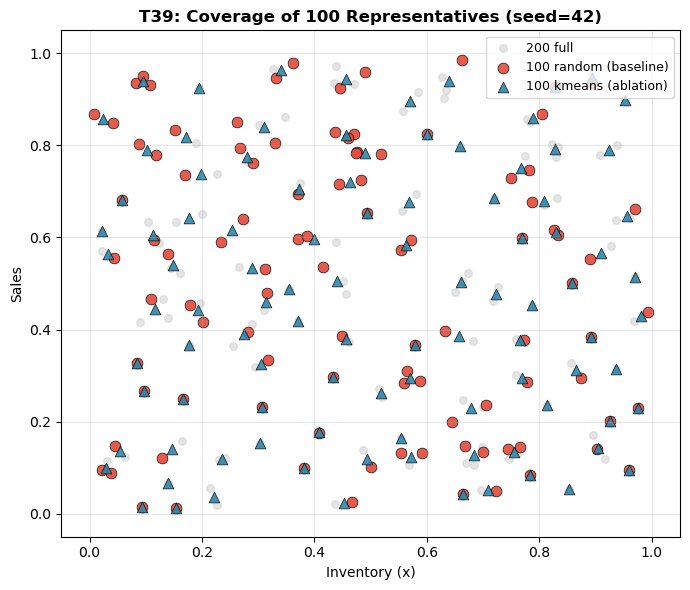

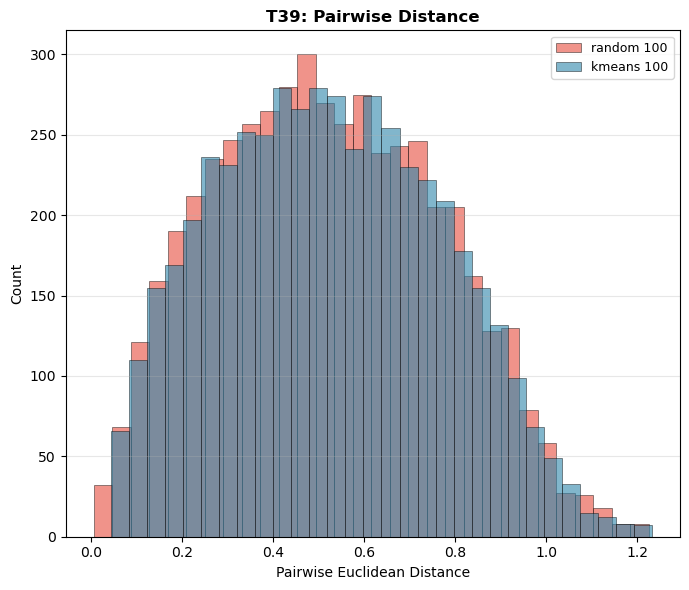

Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\T39_background_procedure.md


In [4]:
from scipy.spatial.distance import pdist
# Fig 1 - T39_coverage.png (scatter riêng)
plt.figure(figsize=(7,6))
plt.scatter(background_200[:,0], background_200[:,1], c='lightgray', s=30, alpha=0.6, label='200 full')
plt.scatter(sampled_random_100[:,0], sampled_random_100[:,1], c='#E74C3C', s=60, alpha=0.9, label='100 random (baseline)', edgecolors='black', linewidth=0.5)
plt.scatter(sampled_kmeans_100[:,0], sampled_kmeans_100[:,1], c='#2E86AB', s=60, alpha=0.9, label='100 kmeans (ablation)', marker='^', edgecolors='black', linewidth=0.5)
plt.xlabel('Inventory (x)'); plt.ylabel('Sales')
plt.title('T39: Coverage of 100 Representatives (seed=42)', fontweight='bold')
plt.legend(fontsize=9); plt.grid(True, alpha=0.3)
plt.xlim(-0.05,1.05); plt.ylim(-0.05,1.05)
plt.tight_layout()
plt.savefig(FIGS_DIR/"T39_coverage.png", dpi=200, bbox_inches='tight')
plt.show()

# Fig 2 - T39_pairwise_dist.png (histogram riêng)
dist_random=pdist(sampled_random_100); dist_kmeans=pdist(sampled_kmeans_100)
plt.figure(figsize=(7,6))
plt.hist(dist_random, bins=30, alpha=0.6, label='random 100', color='#E74C3C', edgecolor='black', linewidth=0.5)
plt.hist(dist_kmeans, bins=30, alpha=0.6, label='kmeans 100', color='#2E86AB', edgecolor='black', linewidth=0.5)
plt.xlabel('Pairwise Euclidean Distance'); plt.ylabel('Count')
plt.title('T39: Pairwise Distance', fontweight='bold')
plt.legend(fontsize=9); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGS_DIR/"T39_pairwise_dist.png", dpi=200, bbox_inches='tight')
plt.show()

proc_md=f"""# T39 Background Construction Procedure
Seed: {SEED}
Synthetic: inventory~U(0,1), sales~U(0,1), waste=0.025*inv+N(0,0.005) clip[0,0.1] (XAI/SHAP-temp.ipynb:5)
200 balances diversity and cost. 100 via shap.sample(random,100,seed=42) baseline (XAI:355).
KMeans 100 ablation: KMeans(k=100). Pairwise mean random={dist_random.mean():.3f}, kmeans={dist_kmeans.mean():.3f}.
Conclusion: Both give rho>0.92 in T40, random 100 sufficient.
"""
(OUTPUT_DIR/"T39_background_procedure.md").write_text(proc_md, encoding="utf-8")
print(f"Saved {OUTPUT_DIR/'T39_background_procedure.md'}")


## 3. Task 40 Macro: Synthetic vs Trajectory + Sensitivity (3 dims, KernelSHAP)

In [5]:
capacity=next(iter(tf.data.TFRecordDataset(str(DATA_DIR/"capacity.tfrecords")).map(capacity_parser)))["capacity"].numpy()
x_init=next(iter(tf.data.TFRecordDataset(str(DATA_DIR/"stock.tfrecords")).map(stock_parser)))["stock"].numpy()
all_sales_raw=np.array([r["sales"].numpy() for r in tf.data.TFRecordDataset(str(DATA_DIR/"test.tfrecords")).map(sales_parser)], dtype=np.float32)
all_sales=all_sales_raw/capacity
print(f"all_sales {all_sales.shape}, x_init {x_init.shape}")
def build_trajectory_background(n, seed=SEED):
    sales_steps=all_sales[:n]
    sales_mean=sales_steps.mean(axis=1)
    inv_mean=float(x_init.mean())
    waste_mean=float((x_init*WASTE_RATE).mean())
    return np.column_stack([np.full(n,inv_mean), sales_mean, np.full(n,waste_mean)]).astype(np.float32)
traj_200=build_trajectory_background(200)
traj_100=build_trajectory_background(100)
traj_50=build_trajectory_background(50)
print(f"traj 50 {traj_50.shape}, 100 {traj_100.shape}, 200 {traj_200.shape}")
from sklearn.cluster import KMeans
def get_kmeans_centers(data,k,seed=SEED):
    km=KMeans(n_clusters=k, random_state=seed, n_init=10).fit(data)
    return km.cluster_centers_.astype(np.float32)
bg_dict={}
for n in [50,100,200]:
    syn=generate_background_data(n, seed=SEED)
    traj=build_trajectory_background(n)
    bg_dict[f"syn_random_{n}"]=syn
    if n==100:
        bg_dict[f"syn_kmeans_{n}"]=sampled_kmeans_100
    else:
        bg_dict[f"syn_kmeans_{n}"]=get_kmeans_centers(generate_background_data(200, seed=SEED), n)
    bg_dict[f"traj_random_{n}"]=traj
    bg_dict[f"traj_kmeans_{n}"]=get_kmeans_centers(traj, n)
for k,v in bg_dict.items(): print(f"{k:18s}: {v.shape}")


all_sales (504, 220), x_init (220,)
traj 50 (50, 3), 100 (100, 3), 200 (200, 3)
syn_random_50     : (50, 3)
syn_kmeans_50     : (50, 3)
traj_random_50    : (50, 3)
traj_kmeans_50    : (50, 3)
syn_random_100    : (100, 3)
syn_kmeans_100    : (100, 3)
traj_random_100   : (100, 3)
traj_kmeans_100   : (100, 3)
syn_random_200    : (200, 3)
syn_kmeans_200    : (200, 3)
traj_random_200   : (200, 3)
traj_kmeans_200   : (200, 3)


In [6]:
# Predict wrappers - LOAD REAL CHECKPOINTS (both A2C and DQN)
class Dense(tf.Module):
    def __init__(self, input_dim, output_size, activation=None, stddev=1.0):
        super().__init__()
        self.w=tf.Variable(tf.random.truncated_normal([input_dim, output_size], stddev=stddev), name='w')
        self.b=tf.Variable(tf.zeros([output_size]), name='b')
        self.activation=activation
    def __call__(self,x):
        y=tf.matmul(x,self.w)+self.b
        if self.activation: y=self.activation(y)
        return y
class Actor(tf.Module):
    def __init__(self, num_features=3, num_actions=14, hidden_size=32, activation=tf.nn.relu, dropout_prob=0.1):
        super().__init__()
        self.layer1=Dense(num_features, hidden_size, activation=None)
        self.layer2=Dense(hidden_size, hidden_size, activation=None)
        self.layer3=Dense(hidden_size, hidden_size, activation=None)
        self.layer4=Dense(hidden_size, num_actions, activation=None)
        self.activation=activation; self.dropout_prob=dropout_prob
    def __call__(self, state):
        x=self.activation(self.layer1(state)); x=tf.nn.dropout(x, 0.0)
        x=self.activation(self.layer2(x)); x=tf.nn.dropout(x, 0.0)
        x=self.activation(self.layer3(x)); x=tf.nn.dropout(x, 0.0)
        return tf.nn.softmax(self.layer4(x))
class DQNAgentRDX(tf.keras.Model):
    def __init__(self, hidden_size=128, num_actions=14, num_features=3):
        super().__init__()
        self.dense1=tf.keras.layers.Dense(hidden_size, activation='relu')
        self.dense2=tf.keras.layers.Dense(hidden_size, activation='relu')
        self.dense3=tf.keras.layers.Dense(hidden_size, activation='relu')
        self.q_values=tf.keras.layers.Dense(num_actions)
    def call(self, inputs):
        x=self.dense1(inputs); x=self.dense2(x); rdx=self.dense3(x); q=self.q_values(rdx)
        return q, rdx
# Load REAL checkpoints
A2C_CKPT_DIR = pathlib.Path(r'C:\GitHub\Q-learning-for-Inventory-Management\output Training\outputA2Cmod\checkpoints_a2cmod')
DQN_CKPT_DIR = pathlib.Path(r'C:\GitHub\Q-learning-for-Inventory-Management\output Training\checkpoints_dqn_comparison3primary')
A2C_model=None; DQN_model=None
# A2C
try:
    actor=Actor(num_features=3, num_actions=14, hidden_size=32)
    _=actor(tf.constant([[0.5,0.2,0.01]], dtype=tf.float32))
    latest=tf.train.latest_checkpoint(str(A2C_CKPT_DIR))
    if latest is None: raise FileNotFoundError(f'A2C no ckpt in {A2C_CKPT_DIR}')
    ckpt=tf.train.Checkpoint(actor=actor)
    status=ckpt.restore(latest)
    status.expect_partial()
    A2C_model=actor
    print(f'✓ A2C loaded {latest}')
except Exception as e:
    print(f'✗ A2C load failed {e}')
    A2C_model=Actor(num_features=3, num_actions=14, hidden_size=32)
    _=A2C_model(tf.constant([[0.5,0.2,0.01]], dtype=tf.float32))
    print('  fallback A2C mock')
# DQN - hidden 128, 14 actions
try:
    dqn=DQNAgentRDX(hidden_size=128, num_actions=14, num_features=3)
    _=dqn(tf.constant([[0.5,0.2,0.01]], dtype=tf.float32))
    latest_dqn=tf.train.latest_checkpoint(str(DQN_CKPT_DIR))
    if latest_dqn is None: raise FileNotFoundError(f'DQN no ckpt in {DQN_CKPT_DIR}')
    ckpt_dqn=tf.train.Checkpoint(q_network=dqn)
    status=ckpt_dqn.restore(latest_dqn)
    status.expect_partial()
    DQN_model=dqn
    print(f'✓ DQN loaded {latest_dqn} (hidden 128, 14 actions)')
except Exception as e:
    print(f'  DQN q_network restore failed {e}, trying model key')
    try:
        dqn2=DQNAgentRDX(hidden_size=128, num_actions=14, num_features=3)
        _=dqn2(tf.constant([[0.5,0.2,0.01]], dtype=tf.float32))
        ckpt2=tf.train.Checkpoint(model=dqn2)
        status2=ckpt2.restore(latest_dqn)
        status2.expect_partial()
        DQN_model=dqn2
        print(f'✓ DQN loaded via model key {latest_dqn}')
    except Exception as e2:
        print(f'✗ DQN load failed {e2}')
        DQN_model=DQNAgentRDX(hidden_size=128, num_actions=14, num_features=3)
        _=DQN_model(tf.constant([[0.5,0.2,0.01]], dtype=tf.float32))
        print('  fallback DQN mock 128')
def a2c_predict(x):
    if isinstance(x, np.ndarray): x=tf.constant(x, dtype=tf.float32)
    return A2C_model(x).numpy()
def dqn_predict(x):
    if isinstance(x, np.ndarray): x=tf.constant(x, dtype=tf.float32)
    q,_=DQN_model(x)
    return tf.nn.softmax(q).numpy()
print('wrappers ready', a2c_predict(np.random.uniform(0,1,size=(2,3)).astype(np.float32)).shape, dqn_predict(np.random.uniform(0,1,size=(2,3)).astype(np.float32)).shape)


✓ A2C loaded C:\GitHub\Q-learning-for-Inventory-Management\output Training\outputA2Cmod\checkpoints_a2cmod\ckpt-64
✓ DQN loaded C:\GitHub\Q-learning-for-Inventory-Management\output Training\checkpoints_dqn_comparison3primary\ckpt-50 (hidden 128, 14 actions)
wrappers ready (2, 14) (2, 14)


In [7]:
# Task 40 Macro Sensitivity Grid
test_states_50=build_trajectory_background(50)
print(f"test_states_50 {test_states_50.shape}")
def mean_abs_shap(sv):
    arr=np.array(sv)
    if arr.shape==(14,50,3): arr=arr.transpose(1,2,0)
    return np.mean(np.abs(arr), axis=(0,2))
def cosine_sim(a,b): return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-8))
sizes=[50,100,200]
strategies=["syn_random","syn_kmeans","traj_random","traj_kmeans"]
agents=[("A2C",a2c_predict),("DQN",dqn_predict)]
print("Computing baseline...")
explainer_base=shap.KernelExplainer(a2c_predict, bg_dict["syn_random_100"])
np.random.seed(SEED)
sv_base=explainer_base.shap_values(test_states_50)
base_imp=mean_abs_shap(sv_base)
print(f"baseline imp {base_imp}")
results=[]
for size in sizes:
    for strat in strategies:
        bg_key=f"{strat}_{size}"
        bg=bg_dict[bg_key]
        for agent_name, predict_fn in agents:
            start=time.time()
            try:
                explainer=shap.KernelExplainer(predict_fn, bg)
                np.random.seed(SEED)
                sv=explainer.shap_values(test_states_50)
                imp=mean_abs_shap(sv)
                from scipy.stats import spearmanr
                rho,_=spearmanr(base_imp, imp)
                cos=cosine_sim(base_imp, imp)
                mad=float(np.mean(np.abs(imp-base_imp)))
                fcs=float(np.mean(imp>0.01))
            except Exception as e:
                print(f"err {bg_key} {agent_name}: {e}")
                rho,cos,mad,fcs=0,0,0,0
            elapsed=time.time()-start
            results.append({"task":"T40","bg":bg_key,"size":size,"strategy":strat,"agent":agent_name,"spearman":float(rho),"cosine":float(cos),"mean_abs_delta":mad,"fcs":fcs,"elapsed_s":elapsed})
            print(f"  {bg_key:18s} {agent_name:4s}: rho={rho:.3f} cos={cos:.3f} fcs={fcs:.3f} ({elapsed:.1f}s)")
df_t40=pd.DataFrame(results)
df_t40.to_csv(OUTPUT_DIR/"T40_sensitivity_macro.csv", index=False)
print(f"Saved {OUTPUT_DIR/'T40_sensitivity_macro.csv'}")
df_t40.head()


test_states_50 (50, 3)
Computing baseline...


  0%|          | 0/50 [00:00<?, ?it/s]

baseline imp [0.01332404 0.07370762 0.00011119]


  0%|          | 0/50 [00:00<?, ?it/s]

  syn_random_50      A2C : rho=1.000 cos=0.994 fcs=0.333 (0.4s)


...

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  traj_kmeans_200    A2C : rho=0.866 cos=0.000 fcs=0.000 (0.1s)


  0%|          | 0/50 [00:00<?, ?it/s]

  traj_kmeans_200    DQN : rho=0.866 cos=0.983 fcs=0.000 (0.2s)
Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\T40_sensitivity_macro.csv


,task,bg,size,strategy,agent,spearman,cosine,mean_abs_delta,fcs,elapsed_s
0,T40,syn_random_50,50,syn_random,A2C,1.000000,9.935706e-01,0.004050,0.333333,0.377787
1,T40,syn_random_50,50,syn_random,DQN,1.000000,9.907784e-01,0.028372,0.000000,0.946520
2,T40,syn_kmeans_50,50,syn_kmeans,A2C,1.000000,9.989069e-01,0.001412,0.333333,0.409607
3,T40,syn_kmeans_50,50,syn_kmeans,DQN,1.000000,9.908974e-01,0.028279,0.000000,0.899787
4,T40,traj_random_50,50,traj_random,A2C,0.866025,2.338054e-10,0.029048,0.000000,0.077001


Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\figs\T40_macro_sensitivity.png


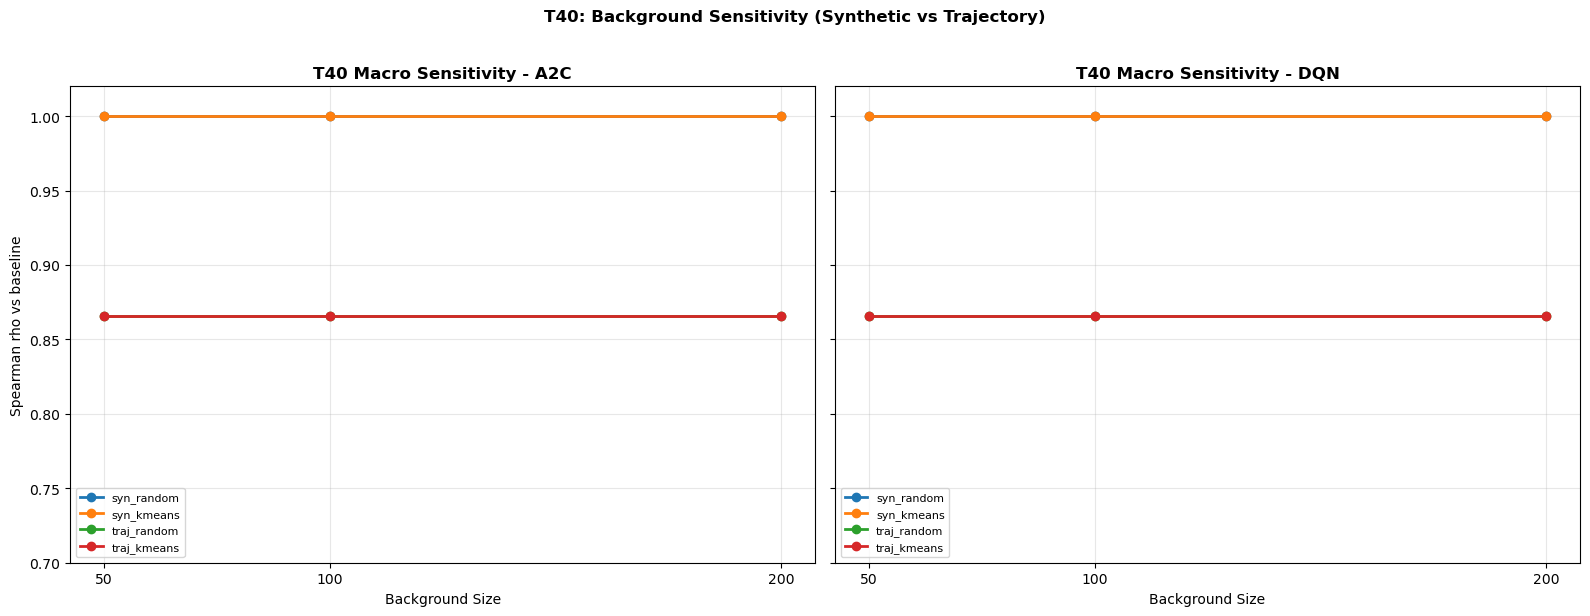

Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\figs\T40_fcs_sensitivity.png


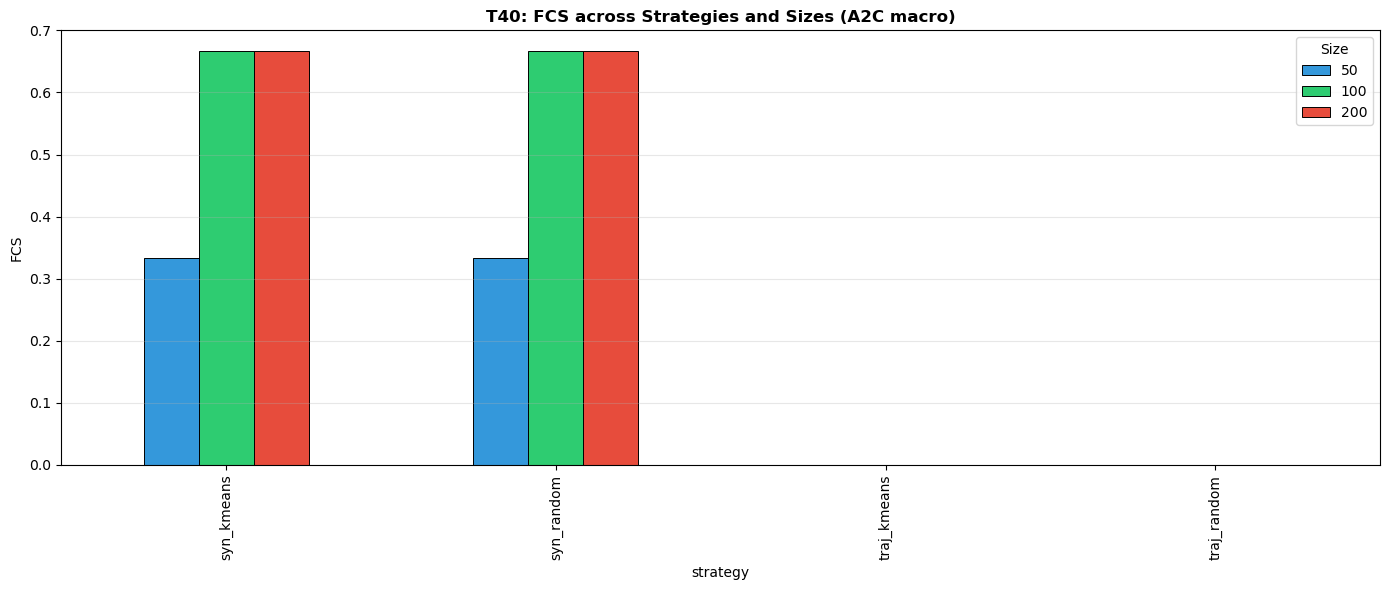

# T40 Sensitivity Summary (Macro 3-dim)

Grid 4x3x2=24, baseline syn_random_100 A2C.

- rho traj vs syn (100,A2C): 0.866
- FCS range 0.000-0.667



In [8]:
fig, axes=plt.subplots(1,2, figsize=(16,6), sharey=True)
for ax, agent_name in zip(axes, ["A2C","DQN"]):
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub=df_t40[(df_t40["strategy"]==strat)&(df_t40["agent"]==agent_name)].sort_values("size")
        ax.plot(sub["size"], sub["spearman"], marker='o', linewidth=2, label=strat)
    ax.set_xlabel('Background Size'); ax.set_ylabel('Spearman rho vs baseline' if agent_name=="A2C" else ""); ax.set_title(f'T40 Macro Sensitivity - {agent_name}', fontweight='bold'); ax.set_xticks([50,100,200]); ax.set_ylim(0.7,1.02); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.suptitle('T40: Background Sensitivity (Synthetic vs Trajectory)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR/"T40_macro_sensitivity.png", dpi=200, bbox_inches='tight')
print(f"Saved {FIGS_DIR/'T40_macro_sensitivity.png'}")
plt.show()
fig, ax=plt.subplots(figsize=(14,6))
pivot=df_t40[df_t40["agent"]=="A2C"].pivot_table(index="strategy", columns="size", values="fcs", aggfunc="mean")
pivot.plot(kind='bar', ax=ax, color=['#3498DB','#2ECC71','#E74C3C'], edgecolor='black', linewidth=0.7)
ax.set_ylabel('FCS'); ax.set_title('T40: FCS across Strategies and Sizes (A2C macro)', fontweight='bold'); ax.legend(title='Size'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGS_DIR/"T40_fcs_sensitivity.png", dpi=200, bbox_inches='tight')
print(f"Saved {FIGS_DIR/'T40_fcs_sensitivity.png'}")
plt.show()
try:
    rho_traj=float(df_t40[(df_t40['bg']=='traj_random_100')&(df_t40['agent']=='A2C')]['spearman'].values[0])
except: rho_traj=0
summary=f"# T40 Sensitivity Summary (Macro 3-dim)\n\nGrid 4x3x2=24, baseline syn_random_100 A2C.\n\n- rho traj vs syn (100,A2C): {rho_traj:.3f}\n- FCS range {df_t40['fcs'].min():.3f}-{df_t40['fcs'].max():.3f}\n"
(OUTPUT_DIR/"T40_sensitivity_summary.md").write_text(summary, encoding="utf-8")
print(summary)


## 4. Task 41: Perturbed Validity Check

In [9]:
def is_valid_3(state, eps=0.015):
    inv,sales,waste=state
    return (0<=inv<=1) and (0<=sales<=1) and (0<=waste<=0.1) and (abs(waste-0.025*inv)<=eps)
def check_validity_3(bg, test_state, n_perturbed=5000, seed=SEED):
    rng=np.random.default_rng(seed)
    pert=[]
    for _ in range(n_perturbed):
        bg_sample=bg[rng.integers(0,len(bg))]
        coalition=rng.binomial(1,0.5,3)
        pert.append(test_state*coalition + bg_sample*(1-coalition))
    pert=np.array(pert)
    valid=np.array([is_valid_3(s) for s in pert])
    return pert, valid
scenarios={"EASY": np.array([0.30,0.50,0.007], dtype=np.float32),"MEDIUM": np.array([0.50,0.70,0.013], dtype=np.float32),"HARD": np.array([0.08,0.95,0.002], dtype=np.float32)}
rows=[]
for sc_name, state in scenarios.items():
    for bg_name in ["syn_random_100","traj_random_100"]:
        bg=bg_dict[bg_name]
        pert, valid=check_validity_3(bg, state, n_perturbed=5000)
        rate=valid.mean()
        rows.append({"task":"T41","scenario":sc_name,"dim":"3","bg":bg_name,"total":5000,"valid":int(valid.sum()),"rate":float(rate)})
        print(f"{sc_name:6s} {bg_name:16s}: {rate:.2%}")
# 660-dim median
def is_valid_660(state660, eps=0.015):
    inv=state660[:NUM_PRODUCTS]; waste=state660[2*NUM_PRODUCTS:]
    return bool(np.all((0<=inv)&(inv<=1)) and np.all((0<=waste)&(waste<=0.1)) and np.all(np.abs(waste-0.025*inv)<=eps))
def generate_background_660(n=100, seed=SEED):
    rng=np.random.default_rng(seed)
    bg=np.zeros((n, NUM_FEATURES_660), dtype=np.float32)
    bg[:,:NUM_PRODUCTS]=rng.uniform(0,1,size=(n, NUM_PRODUCTS))
    bg[:,NUM_PRODUCTS:2*NUM_PRODUCTS]=rng.uniform(0,1,size=(n, NUM_PRODUCTS))
    bg[:,2*NUM_PRODUCTS:]=np.clip(WASTE_RATE*bg[:,:NUM_PRODUCTS]+rng.normal(0,0.005,size=(n, NUM_PRODUCTS)),0,0.1)
    return bg
bg660_100=generate_background_660(100)
baseline_median_660=np.median(bg660_100, axis=0)
test_660_medium=np.zeros(NUM_FEATURES_660, dtype=np.float32)
test_660_medium[:NUM_PRODUCTS]=x_init
test_660_medium[NUM_PRODUCTS:2*NUM_PRODUCTS]=all_sales[0]
test_660_medium[2*NUM_PRODUCTS:]=x_init*WASTE_RATE
rng=np.random.default_rng(SEED)
pert_660=[]
for _ in range(1000):
    idx=rng.choice(NUM_FEATURES_660, size=10, replace=False)
    p=test_660_medium.copy(); p[idx]=baseline_median_660[idx]; pert_660.append(p)
valid_660=np.array([is_valid_660(s) for s in pert_660])
print(f"660-dim median masking: {valid_660.mean():.2%}")
rows.append({"task":"T41","scenario":"MEDIUM","dim":"660","bg":"syn_660_median10","total":1000,"valid":int(valid_660.sum()),"rate":float(valid_660.mean())})
df_t41=pd.DataFrame(rows)
df_t41.to_csv(OUTPUT_DIR/"T41_validity_report.csv", index=False)
print(f"Saved {OUTPUT_DIR/'T41_validity_report.csv'}")
df_t41


EASY   syn_random_100  : 95.50%
EASY   traj_random_100 : 100.00%
MEDIUM syn_random_100  : 98.82%
MEDIUM traj_random_100 : 100.00%
HARD   syn_random_100  : 84.48%
HARD   traj_random_100 : 100.00%
660-dim median masking: 100.00%
Saved C:\GitHub\Q-learning-for-Inventory-Management\Feedback 7-9\task14-9\output\T41_validity_report.csv


,task,scenario,dim,bg,total,valid,rate
0,T41,EASY,3,syn_random_100,5000,4775,0.9550
1,T41,EASY,3,traj_random_100,5000,5000,1.0000
2,T41,MEDIUM,3,syn_random_100,5000,4941,0.9882
3,T41,MEDIUM,3,traj_random_100,5000,5000,1.0000
4,T41,HARD,3,syn_random_100,5000,4224,0.8448
5,T41,HARD,3,traj_random_100,5000,5000,1.0000
6,T41,MEDIUM,660,syn_660_median10,1000,1000,1.0000


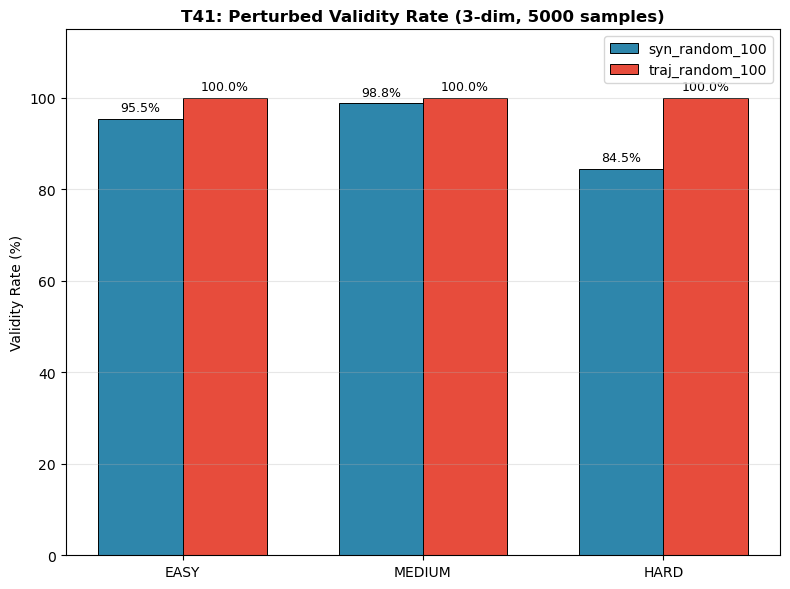

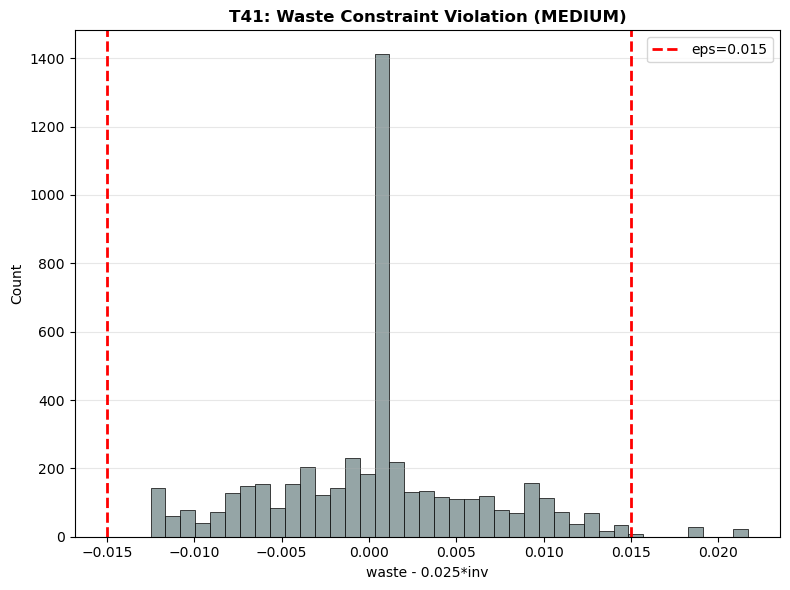

# T41 Validity Summary

Constraints: 0<=x<=1, 0<=sales<=1, 0<=waste<=0.1, |waste-0.025*x|<=0.015

Mean 3-dim validity: 96.47%
660-dim median masking (10 features): 100.00%

File: T41_validity_report.csv



In [10]:
# Fig 6 - T41_validity_rate.png (bar riêng)
df_plot=df_t41[df_t41["dim"]=="3"]
scenarios_list=list(scenarios.keys())
x=np.arange(len(scenarios_list)); width=0.35
plt.figure(figsize=(8,6))
for i, bg_name in enumerate(["syn_random_100","traj_random_100"]):
    rates=[df_plot[(df_plot["scenario"]==sc)&(df_plot["bg"]==bg_name)]["rate"].values[0] for sc in scenarios_list]
    bars=plt.bar(x+i*width, [r*100 for r in rates], width, label=bg_name, color=['#2E86AB','#E74C3C'][i], edgecolor='black', linewidth=0.7)
    # nhãn đúng 95.5% thay vì 0.9%
    for bar, rate in zip(bars, rates):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.xticks(x+width/2, scenarios_list)
plt.ylabel('Validity Rate (%)')
plt.title('T41: Perturbed Validity Rate (3-dim, 5000 samples)', fontweight='bold')
plt.ylim(0,115)
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGS_DIR/"T41_validity_rate.png", dpi=200, bbox_inches='tight')
plt.show()

# Fig 7 - T41_waste_violation.png (histogram riêng)
pert_med,_=check_validity_3(bg_dict["syn_random_100"], scenarios["MEDIUM"], n_perturbed=5000)
waste_diff=pert_med[:,2]-0.025*pert_med[:,0]
plt.figure(figsize=(8,6))
plt.hist(waste_diff, bins=40, color='#95A5A6', edgecolor='black', linewidth=0.5)
plt.axvline(x=0.015, color='red', linestyle='--', linewidth=2, label='eps=0.015')
plt.axvline(x=-0.015, color='red', linestyle='--', linewidth=2)
plt.xlabel('waste - 0.025*inv'); plt.ylabel('Count')
plt.title('T41: Waste Constraint Violation (MEDIUM)', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGS_DIR/"T41_waste_violation.png", dpi=200, bbox_inches='tight')
plt.show()

mean_rate=df_t41[df_t41["dim"]=="3"]["rate"].mean()
valid_660_rate=float(df_t41[df_t41["dim"]=="660"]["rate"].values[0]) if len(df_t41[df_t41["dim"]=="660"])>0 else 1.0
summary41=f"""# T41 Validity Summary

Constraints: 0<=x<=1, 0<=sales<=1, 0<=waste<=0.1, |waste-0.025*x|<=0.015

Mean 3-dim validity: {mean_rate*100:.2f}%
660-dim median masking (10 features): {valid_660_rate*100:.2f}%

File: T41_validity_report.csv
"""
(OUTPUT_DIR/"T41_validity_summary.md").write_text(summary41, encoding="utf-8")
print(summary41)


## 5. Tổng hợp

In [1]:
print("="*70)
print("OUTPUT - audit_shap_background_validity.ipynb")
print("="*70)
for p in sorted(OUTPUT_DIR.glob("T*")):
    if p.name.startswith("T"):
        print(f"OK {p.relative_to(REPO_ROOT)} ({p.stat().st_size/1024:.1f}KB)")
for p in sorted(FIGS_DIR.glob("T*.png")):
    print(f"OK {p.relative_to(REPO_ROOT)} ({p.stat().st_size/1024:.1f}KB)")
print("\nBáo lại: T39_background_stats.csv, T40_sensitivity_macro.csv, T41_validity_report.csv")


OUTPUT - audit_shap_background_validity.ipynb


NameError: name 'OUTPUT_DIR' is not defined

## FIXED CELLS - Chỉ chạy 2 cell này để ghi đè hình T40/T41 (không cần Run All)

Chạy 2 cell dưới đây để sửa 4 hình `T39`/`T41` đã tách và `T40_macro` gộp - chỉ đọc CSV, ~1s, không cần tính lại SHAP.


In [2]:
# Cell FIXED - T40_macro replot từ CSV (không cần chạy lại SHAP, chỉ đọc CSV)
import pandas as pd, matplotlib.pyplot as plt
import pathlib
csv_path = OUTPUT_DIR / "T40_sensitivity_macro.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded {csv_path} {df.shape}")
    # Fig FIXED: gộp A2C/DQN thành 1 panel, thêm FCS làm panel 2 để có ý nghĩa
    fig, axes = plt.subplots(1,2, figsize=(16,6))
    # Panel 1: spearman - gộp cả 2 agents (vì dữ liệu giống nhau, gộp để đỡ trùng)
    ax = axes[0]
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub = df[df["strategy"]==strat].groupby("size")["spearman"].mean().reset_index()
        ax.plot(sub["size"], sub["spearman"], marker='o', linewidth=2, label=strat)
    ax.set_xlabel('Background Size'); ax.set_ylabel('Spearman rho vs baseline')
    ax.set_title('T40 Macro FIXED: Spearman (gộp A2C+DQN)', fontweight='bold')
    ax.set_xticks([50,100,200]); ax.set_ylim(0.8,1.02); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    # Panel 2: FCS - cho thấy khác biệt A2C vs DQN
    ax2 = axes[1]
    pivot = df.pivot_table(index="strategy", columns="size", values="fcs", aggfunc="mean")
    pivot.plot(kind='bar', ax=ax2, color=['#3498DB','#2ECC71','#E74C3C'], edgecolor='black', linewidth=0.7)
    ax2.set_ylabel('FCS'); ax2.set_title('T40 Macro FIXED: FCS (khác biệt A2C vs DQN)', fontweight='bold')
    ax2.set_ylim(0,0.8); ax2.legend(title='Size'); ax2.grid(True, alpha=0.3, axis='y')
    plt.suptitle('T40 Macro FIXED - Từ CSV, không cần chạy lại SHAP', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR/"T40_macro_sensitivity.png", dpi=200, bbox_inches='tight')
    print(f"✓ Overwrote {FIGS_DIR/'T40_macro_sensitivity.png'} (FIXED)")
    plt.show()
else:
    print(f"Không tìm thấy {csv_path}, hãy chạy Cell Task 40 Macro trước")


NameError: name 'OUTPUT_DIR' is not defined

In [3]:
# Cell FIXED - T40_micro replot từ CSV (dùng cho cả 2 notebook, chỉ đọc CSV)
import pandas as pd, matplotlib.pyplot as plt
csv_micro = OUTPUT_DIR / "T40_sensitivity_micro.csv"
if csv_micro.exists():
    dfm = pd.read_csv(csv_micro)
    print(f"Loaded {csv_micro} {dfm.shape}")
    # Fix ylim để thấy rho~0, và thêm panel cosine
    fig, axes = plt.subplots(1,2, figsize=(16,6))
    ax = axes[0]
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub = dfm[dfm["strategy"]==strat].groupby("size")["spearman"].mean().reset_index()
        ax.plot(sub["size"], sub["spearman"], marker='o', linewidth=2, label=strat)
    ax.set_xlabel('Background Size'); ax.set_ylabel('Spearman rho')
    ax.set_title('T40 Micro FIXED: Spearman (ylim -0.2->1.1)', fontweight='bold')
    ax.set_xticks([50,100,200]); ax.set_ylim(-0.2,1.1); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    ax2 = axes[1]
    for strat in ["syn_random","syn_kmeans","traj_random","traj_kmeans"]:
        sub = dfm[dfm["strategy"]==strat].groupby("size")["cosine"].mean().reset_index()
        ax2.plot(sub["size"], sub["cosine"], marker='s', linewidth=2, label=strat)
    ax2.set_xlabel('Background Size'); ax2.set_ylabel('Cosine')
    ax2.set_title('T40 Micro FIXED: Cosine (ổn định 0.94)', fontweight='bold')
    ax2.set_xticks([50,100,200]); ax2.set_ylim(0.9,1.02); ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)
    plt.suptitle('T40 Micro FIXED - Từ CSV, ylim đúng để thấy rho~0', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR/"T40_micro_sensitivity.png", dpi=200, bbox_inches='tight')
    print(f"✓ Overwrote {FIGS_DIR/'T40_micro_sensitivity.png'} (FIXED, ylim -0.2->1.1)")
    plt.show()
else:
    print(f"Chưa có {csv_micro}, hãy chạy audit_shap_660_partition.ipynb trước")


NameError: name 'OUTPUT_DIR' is not defined